# Linear Regression

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import patsy as pt 

In [8]:
hospital = pd.read_csv("https://raw.githubusercontent.com/roualdes/data/refs/heads/master/hospital.csv")

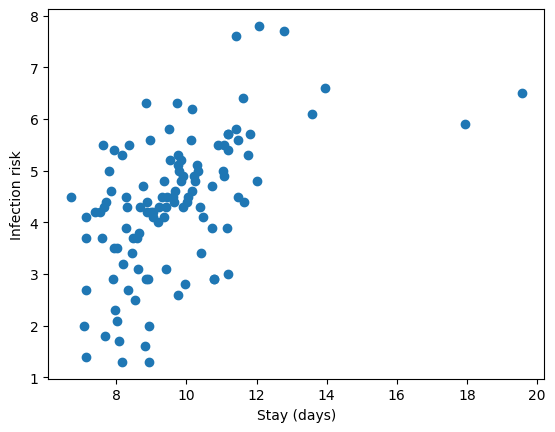

In [15]:
plt.scatter(hospital["stay"], hospital["infection_risk"])
plt.xlabel("Stay (days)")
plt.ylabel("Infection risk");

In [29]:
fit = smf.ols("infection_risk ~ nurses * stay", data = hospital).fit()
fit.summary()

Notes: [1] Standard Errors assume that the covariance matrix of the errors is correctly specified. [2] The condition number is large, 2.27e+04. This might indicate that there are strong multicollinearity or other numerical problems.

In [30]:
ndf = pd.DataFrame.from_dict({"stay": [20, 20], "nurses": [100, 101]})
np.diff(fit.predict(ndf))

array([-0.00447639])

For each extra nurse, when stay is equal to 20, we expect infection risk
to **decrease** by 0.004.

In [32]:
ndf = pd.DataFrame.from_dict({"stay": [10, 10], "nurses": [100, 101]})
np.diff(fit.predict(ndf))

array([0.00221305])

For each extra nurse, when stay is equal to 10, we expect infection risk
to **increase** by 0.002.

# Logistic Regression

In [34]:
# change hospital -> possum
possum = pd.read_csv("https://raw.githubusercontent.com/roualdes/data/refs/heads/master/possum.csv")

In [38]:
possum["vic"] = (possum["pop"] == "vic").astype(np.float64)

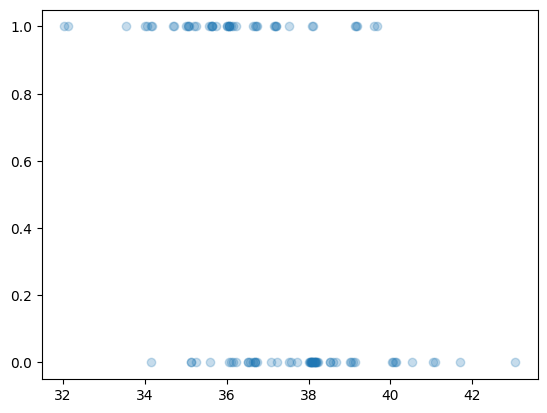

In [43]:
rng = np.random.default_rng()
N = np.shape(possum)[0]
plt.scatter(possum["tailL"] + rng.uniform(size = N) * 0.25, possum["vic"], 
            alpha = 0.25);

In [46]:
fit = smf.glm("vic ~ tailL", data = possum, 
              family = sm.families.Binomial()).fit()

In [47]:
fit.summary()

In [48]:
x = np.linspace(32, 44, 101)
ndf = pd.DataFrame.from_dict({"tailL": x})
fit.predict(ndf)

0      0.959987
1      0.956634
2      0.953015
3      0.949109
4      0.944897
         ...   
96     0.007524
97     0.006922
98     0.006368
99     0.005858
100    0.005389
Length: 101, dtype: float64